In [1]:
import pandas as pd
import gc
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
hitc = pd.read_parquet("Model/ga_hits-001.parquet")

In [3]:
hits = hitc[["session_id", "event_action"]].copy()


In [4]:
del hitc

In [5]:
gc.collect()

0

In [6]:
target_actions = ['sub_car_claim_click', 'sub_car_claim_submit_click', 'sub_open_dialog_click', 'sub_custom_question_submit_click', 'sub_call_number_click', 'sub_callback_submit_click', 'sub_submit_success', 'sub_car_request_submit_click']

In [7]:
hits['is_target'] = hits['event_action'].isin(target_actions).astype('int8')

In [8]:
target_df = (hits.groupby('session_id', as_index=False)['is_target'].max().rename(columns={'is_target': 'target'}))

In [9]:
target_df.target.value_counts(normalize=True)

target
0    0.970737
1    0.029263
Name: proportion, dtype: float64

In [10]:
del hits

In [11]:
gc.collect()

0

In [13]:
sessions = pd.read_parquet("Model/ga_sessions.parquet")

In [14]:
sessions['session_id'] = sessions['session_id'].astype(str)

In [15]:
target_df['session_id'] = target_df['session_id'].astype(str)

In [16]:
df = sessions.merge(target_df, on='session_id', how='left')

In [17]:
df["target"] = df["target"].fillna(0).astype("int8")

In [18]:
df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


## Data preparation

### Data cleaning

In [19]:
print('Размер выборки: {}, {}'.format(df.shape[0], df.shape[1]))

Размер выборки: 1860042, 19


In [20]:
print('Информация о выборке:\n')
df.info()

Информация о выборке:

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 19 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                str   
 1   client_id                 str   
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                str   
 6   utm_medium                str   
 7   utm_campaign              str   
 8   utm_adcontent             str   
 9   utm_keyword               str   
 10  device_category           str   
 11  device_os                 str   
 12  device_brand              str   
 13  device_model              str   
 14  device_screen_resolution  str   
 15  device_browser            str   
 16  geo_country               str   
 17  geo_city                  str   
 18  target                    int8  
dtypes: int64(1), int8(1), object(2), str(15)
memory usage: 563.2+ MB


#### Duplicates cleaning

In [21]:
print('Информация о дубликатах выборки:')
df.duplicated(subset="session_id").sum()

Информация о дубликатах выборки:


np.int64(0)

#### Missing Values Handling

Наиболее проседающие по заполненным значениям признаки


<Axes: >

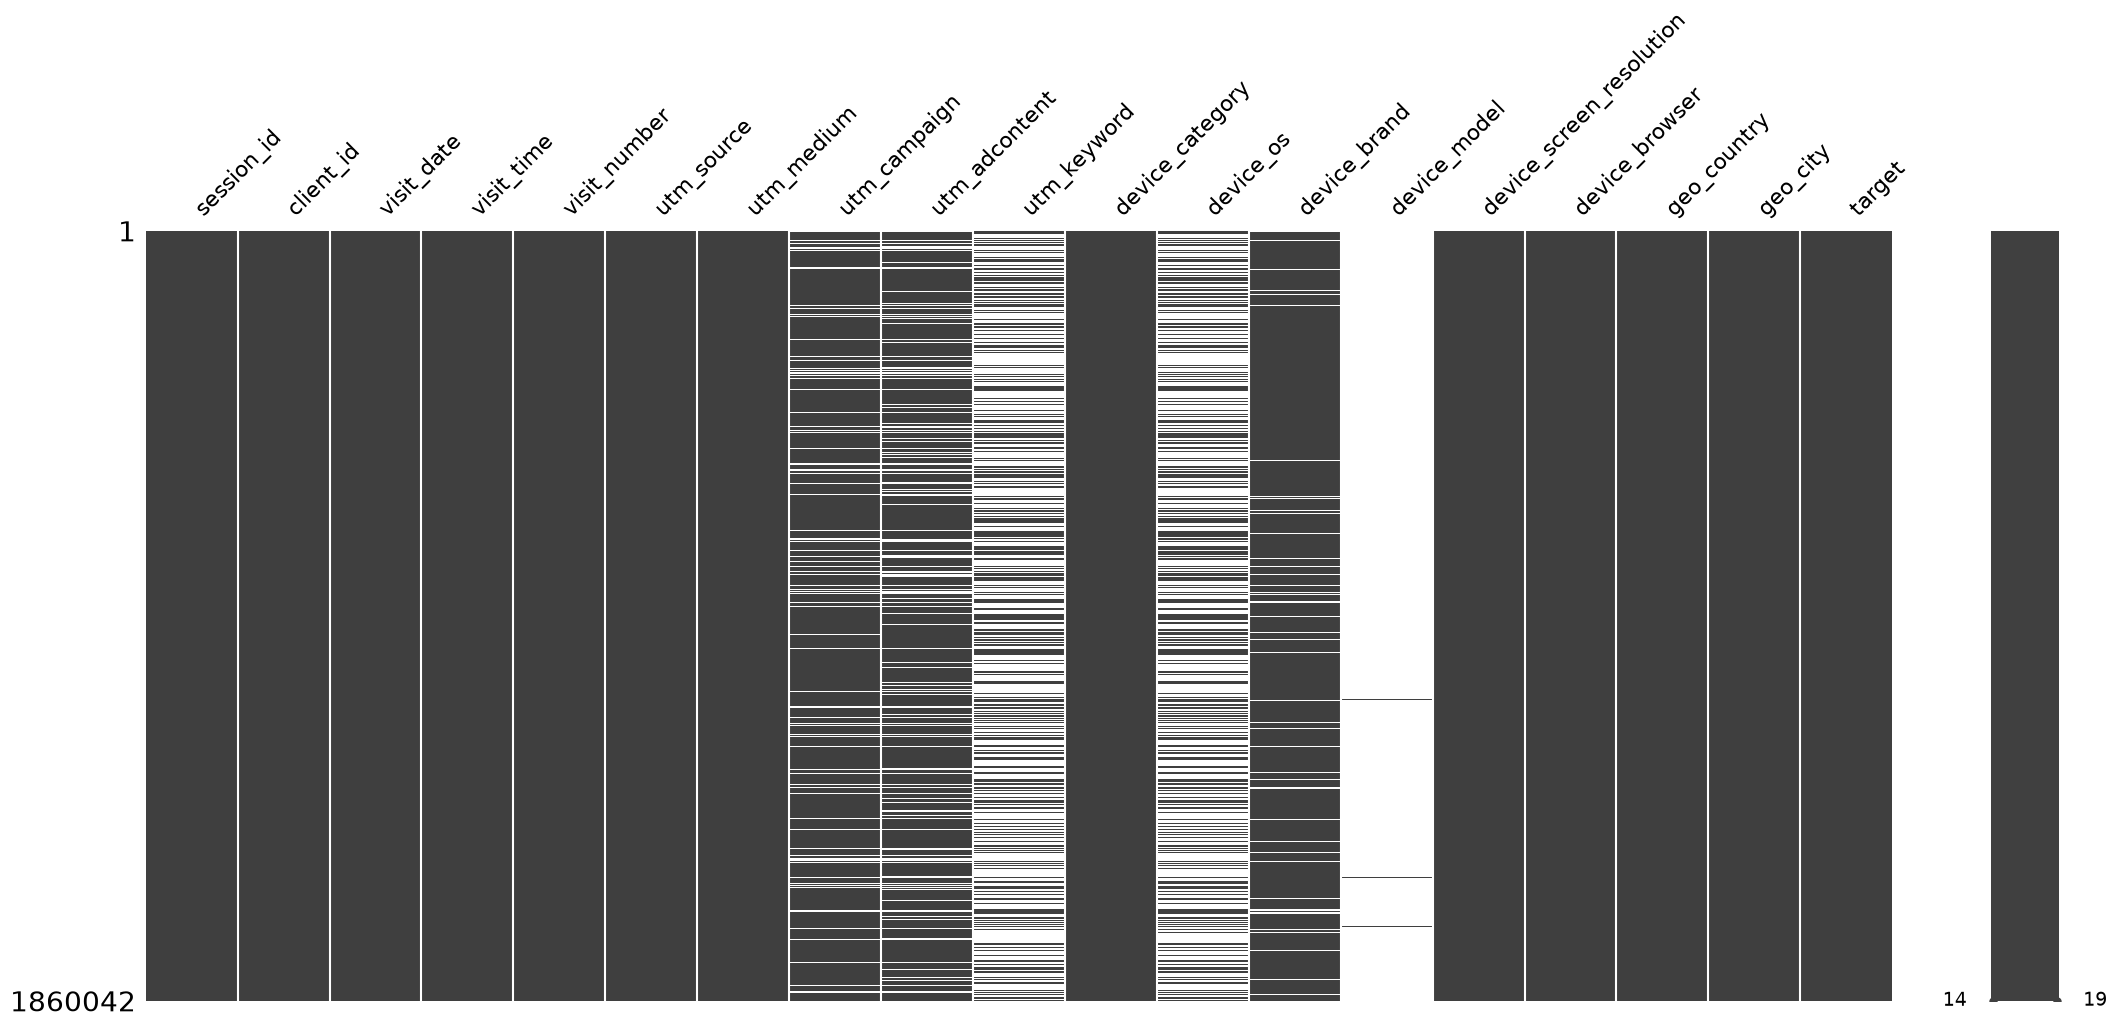

In [22]:
print('Наиболее проседающие по заполненным значениям признаки')
msno.matrix(df)

In [23]:
missing_values = ((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)
print('Процент пропущенных значений:')
missing_values

Процент пропущенных значений:


device_model                99.121633
utm_keyword                 58.174009
device_os                   57.533002
utm_adcontent               18.043410
utm_campaign                11.806346
device_brand                 6.380394
utm_source                   0.005215
visit_date                   0.000000
client_id                    0.000000
session_id                   0.000000
utm_medium                   0.000000
device_category              0.000000
visit_time                   0.000000
visit_number                 0.000000
device_screen_resolution     0.000000
device_browser               0.000000
geo_country                  0.000000
geo_city                     0.000000
target                       0.000000
dtype: float64

In [24]:
df = df.drop(columns=["device_model"])

In [25]:
df["utm_source"] = df["utm_source"].fillna("unknown_source")

In [26]:
print(df.groupby("device_category")["device_os"].apply(lambda x: x.isna().mean() * 100))

device_category
desktop    67.660952
mobile     54.939110
tablet     63.545991
Name: device_os, dtype: float64


In [27]:
print(df[df["device_os"].isna()]["device_browser"].value_counts().head(15))

device_browser
Chrome                              541709
Safari                              288063
YaBrowser                            83094
Safari (in-app)                      52330
Android Webview                      37156
Samsung Internet                     25814
Opera                                19777
Firefox                              10691
Edge                                  9822
UC Browser                             494
Android Runtime                        297
[FBAN                                  245
Instagram 208.0.0.32.135 Android       140
Instagram 209.0.0.21.119 Android       111
Mozilla Compatible Agent                60
Name: count, dtype: int64


In [28]:
df["device_os"] = df["device_os"].fillna("os_not_detected")

In [29]:
#для этих трёх колонок гипотеза одна и та же: пропуски, скорее всего, связаны с органическим/прямым трафиком, у которого физически не может быть рекламных атрибутов (нет кампании — нет ключевика — нет рекламного контента)
for col in ["utm_keyword", "utm_campaign", "utm_adcontent"]:
    print(f"--- {col} ---")
    print(df.groupby("utm_medium")[col].apply(lambda x: x.isna().mean() * 100))
    print()

--- utm_keyword ---
utm_medium
(none)                77.203693
(not set)             42.083333
CPM                    0.000000
Sbol_catalog           0.000000
app                    0.000000
article               70.588235
banner                41.952878
blogger_channel       70.205864
blogger_header        95.979248
blogger_stories       89.540816
catalogue            100.000000
cbaafe               100.000000
clicks                70.235546
cpa                   93.549895
cpc                   67.108102
cpm                   52.208953
cpv                   99.663426
desktop                0.000000
dom_click              0.000000
email                 45.379617
fb_smm                 0.000000
google_cpc             0.000000
info_text              0.000000
landing               86.567164
landing_interests      0.000000
last                 100.000000
link                  78.947368
linktest               0.000000
main_polka             0.000000
medium                 0.000000
nkp      

In [30]:
#Тут гипотеза сработала почти идеально — пропуски сконцентрированы у cpc (48.7%) и referral (3.7%), у большинства остальных типов — 0%
df["utm_campaign"] = df["utm_campaign"].fillna("no_campaign")

In [31]:
#Похожая картина — пропуски у cpa (88.5%), cpc (73.9%), остальное близко к нулю
df["utm_adcontent"] = df["utm_adcontent"].fillna("no_adcontent")

In [32]:
#Конкретное значение ключевого слова ненадёжно и хаотично, но сам факт "было или нет" может быть слабым, но осмысленным сигналом — лучше свести к простому флагу, чем тащить в модель почти случайный шум из сотен уникальных слов
df["has_keyword"] = df["utm_keyword"].notna().astype("int8")
df = df.drop(columns=["utm_keyword"])

In [33]:
#Проверем долю пропушеных брендов по девайсам
print(df.groupby("device_category")["device_brand"].apply(lambda x: x.isna().mean() * 100))

device_category
desktop    32.324056
mobile      0.005153
tablet      0.092856
Name: device_brand, dtype: float64


In [34]:
print(f'Кол-во пропушеных mobile: {df[(df["device_category"] == "mobile") & (df["device_brand"].isna())].shape[0]}')
print(f'Кол-во пропушеных tablet: {df[(df["device_category"] == "tablet") & (df["device_brand"].isna())].shape[0]}')

Кол-во пропушеных mobile: 76
Кол-во пропушеных tablet: 17


In [35]:
print(df[(df["device_category"] == "mobile") & (df["device_brand"].isna())]["device_os"].value_counts())
print(df[(df["device_category"] == "tablet") & (df["device_brand"].isna())]["device_os"].value_counts())

device_os
Linux        50
Windows      16
Macintosh    10
Name: count, dtype: int64
device_os
Macintosh    10
Linux         7
Name: count, dtype: int64


In [36]:
#Замена пропушенных значений
mask_desktop = df["device_category"] == "desktop"
mask_other_missing = df["device_brand"].isna() & ~mask_desktop
df.loc[mask_desktop, "device_brand"] = df.loc[mask_desktop, "device_brand"].fillna("desktop_no_brand")
df.loc[mask_other_missing, "device_brand"] = "brand_unknown"

In [37]:
missing_values = ((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)
print('Процент пропущенных значений:')
missing_values

Процент пропущенных значений:


session_id                  0.0
client_id                   0.0
visit_date                  0.0
visit_time                  0.0
visit_number                0.0
utm_source                  0.0
utm_medium                  0.0
utm_campaign                0.0
utm_adcontent               0.0
device_category             0.0
device_os                   0.0
device_brand                0.0
device_screen_resolution    0.0
device_browser              0.0
geo_country                 0.0
geo_city                    0.0
target                      0.0
has_keyword                 0.0
dtype: float64

#### Data Types Correction

In [38]:
df.dtypes

session_id                     str
client_id                      str
visit_date                  object
visit_time                  object
visit_number                 int64
utm_source                     str
utm_medium                     str
utm_campaign                   str
utm_adcontent                  str
device_category                str
device_os                      str
device_brand                   str
device_screen_resolution       str
device_browser                 str
geo_country                    str
geo_city                       str
target                        int8
has_keyword                   int8
dtype: object

In [39]:
df["visit_date"] = pd.to_datetime(df["visit_date"])

In [40]:
df["visit_number"] = df["visit_number"].astype("int32")

In [41]:
categorical_cols = [
    "utm_source", "utm_medium", "utm_campaign", "utm_adcontent",
    "device_category", "device_os", "device_brand",
    "device_browser", "geo_country", "geo_city"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [42]:
print(df.dtypes)
print(df.memory_usage(deep=True).sum() / 1024**2, "МБ")

session_id                            str
client_id                             str
visit_date                  datetime64[s]
visit_time                         object
visit_number                        int32
utm_source                       category
utm_medium                       category
utm_campaign                     category
utm_adcontent                    category
device_category                  category
device_os                        category
device_brand                     category
device_screen_resolution              str
device_browser                   category
geo_country                      category
geo_city                         category
target                               int8
has_keyword                          int8
dtype: object
302.8342037200928 МБ


#### Outliers and Anomalies Handling

In [43]:
df_clean = df.copy()

In [44]:
def calculate_outliers(data):
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    iqr = q75 - q25
    boundaries = (q25 - 1.5 * iqr, q75 + 1.5 * iqr)
    return boundaries

##### Анализ аномалий и выбросов в visit_number

In [45]:
df_clean.visit_number.describe()

count    1.860042e+06
mean     2.712804e+00
std      1.182907e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      5.640000e+02
Name: visit_number, dtype: float64

In [46]:
#Как распределён target в зависимости от количества визитов
print(df_clean.groupby("visit_number")["target"].agg(["count", "mean"]).head(20))

                count      mean
visit_number                   
1             1376349  0.023516
2              235656  0.032293
3               81068  0.037586
4               41666  0.043945
5               24271  0.044250
6               16473  0.048504
7               11640  0.045533
8                8735  0.045220
9                6692  0.046922
10               5413  0.047478
11               4473  0.046948
12               3702  0.039168
13               3131  0.044075
14               2672  0.043413
15               2318  0.041846
16               2020  0.038119
17               1794  0.040691
18               1606  0.044209
19               1430  0.041958
20               1296  0.042438


In [47]:
q99 = df_clean["visit_number"].quantile(0.99)
print(f"99-й перцентиль: {q99}")

print("CR у обычных пользователей (<=99 перцентиль):")
print(df_clean[df_clean["visit_number"] <= q99]["target"].mean())

print("CR у экстремальных пользователей (>99 перцентиля):")
print(df_clean[df_clean["visit_number"] > q99]["target"].mean())

print("Количество строк в каждой группе:")
print((df_clean["visit_number"] <= q99).sum())
print((df_clean["visit_number"] > q99).sum())

99-й перцентиль: 32.0
CR у обычных пользователей (<=99 перцентиль):
0.026917385909802975
CR у экстремальных пользователей (>99 перцентиля):
0.04031075134459716
Количество строк в каждой группе:
1841635
18407


In [48]:
q999 = df_clean["visit_number"].quantile(0.999)
print(f"99.9-й перцентиль: {q999}")

print("CR у пользователей выше 99.9 перцентиля:")
print(df_clean[df_clean["visit_number"] > q999]["target"].mean())
print("Количество таких строк:")
print((df_clean["visit_number"] > q999).sum())

99.9-й перцентиль: 189.0
CR у пользователей выше 99.9 перцентиля:
0.11334056399132321
Количество таких строк:
1844


Проверка visit_number показала, что CR растёт вместе с числом визитов: 2.69% у пользователей ≤ 99-го перцентиля против 4.03% выше 99-го и 11.34% выше 99.9-го перцентиля. Экстремальные значения оказались не аномалией, а сильным предиктором конверсии, поэтому колонка оставлена без изменений.

##### Анализ аномалий и выбросов в visit_date

In [49]:
print(df_clean["visit_date"].min())
print(df_clean["visit_date"].max())

2021-05-19 00:00:00
2021-12-31 00:00:00


In [50]:
daily_counts = df_clean["visit_date"].value_counts().sort_index()
print(daily_counts.describe())

count      226.000000
mean      8230.274336
std       4311.557692
min        877.000000
25%       5467.250000
50%       7326.000000
75%      10309.000000
max      39453.000000
Name: count, dtype: float64


In [51]:
print("Дни с наименьшим числом визитов:")
print(daily_counts.sort_values().head(10))

print("Дни с наибольшим числом визитов:")
print(daily_counts.sort_values(ascending=False).head(10))

Дни с наименьшим числом визитов:
visit_date
2021-05-19     877
2021-05-22     986
2021-05-21    1110
2021-05-23    1246
2021-06-05    2102
2021-06-06    2298
2021-06-04    2615
2021-06-08    2750
2021-08-01    2894
2021-06-07    2956
Name: count, dtype: int64
Дни с наибольшим числом визитов:
visit_date
2021-05-24    39453
2021-12-21    30704
2021-05-25    19305
2021-06-29    17367
2021-09-14    16204
2021-12-31    15910
2021-10-29    15818
2021-11-16    15253
2021-06-28    15169
2021-11-15    15009
Name: count, dtype: int64


Распределение визитов по датам показало три заметных отклонения от среднего (8230 визитов/день): спад в конце мая 2021 (877–1246 визитов) непосредственно перед запуском сервиса, резкий пик 24 мая 2021 (39 453 визита) — в день запуска, и пик 21 декабря 2021 (30 704 визита), вероятно связанный с предновогодней активностью. Все отклонения объясняются реальными бизнес-событиями, а не ошибками данных, поэтому колонка visit_date оставлена без изменений

##### Анализ аномалий и выбросов в device_screen_resolution

In [52]:
print(df_clean["device_screen_resolution"].value_counts().head(15))

device_screen_resolution
414x896      169090
1920x1080    125768
375x812      117944
393x851      115454
375x667       93341
360x780       92182
360x800       80547
412x915       74744
360x640       70588
390x844       60827
393x873       52056
360x720       50603
360x760       50467
412x892       43944
428x926       40690
Name: count, dtype: int64


In [53]:
print(df_clean["device_screen_resolution"].value_counts().tail(15))

device_screen_resolution
442x706      1
2350x1322    1
441x917      1
1456x819     1
450x1012     1
2550x1440    1
374x604      1
2240x960     1
450x1091     1
432x915      1
483x1063     1
565x1255     1
412x763      1
1905x1080    1
464x1123     1
Name: count, dtype: int64


In [54]:
print(df_clean["device_screen_resolution"].nunique())

5039


In [55]:
suspicious = df_clean["device_screen_resolution"].isin(["0x0", "(not set)", "1x1", ""])
print(suspicious.sum())

19


In [56]:
print(df_clean[suspicious]["device_screen_resolution"].value_counts())

device_screen_resolution
0x0          11
(not set)     8
Name: count, dtype: int64


In [57]:
df_clean.loc[suspicious, "device_screen_resolution"] = np.nan

In [58]:
print(df_clean["device_screen_resolution"].isna().sum())

19


При проверке device_screen_resolution на технические аномалии обнаружено 19 строк (0.001% датасета) с заглушками "0x0" (11 строк) и "(not set)" (8 строк). Эти значения заменены на пропуски и впоследствии будут заполнены медианными значениями при разбиении признака на screen_width и screen_height, ввиду их незначительного объёма

#### Final Data Cleaning Check

После обработки пропусков, дубликатов, типов данных и аномальных значений была выполнена финальная проверка качества очищенного датасета.

In [59]:
print(df_clean.shape)
print(df_clean.memory_usage(deep=True).sum() / 1024**2, "МБ")

(1860042, 18)
302.97472858428955 МБ


In [60]:
print(df_clean.isna().sum())

session_id                   0
client_id                    0
visit_date                   0
visit_time                   0
visit_number                 0
utm_source                   0
utm_medium                   0
utm_campaign                 0
utm_adcontent                0
device_category              0
device_os                    0
device_brand                 0
device_screen_resolution    19
device_browser               0
geo_country                  0
geo_city                     0
target                       0
has_keyword                  0
dtype: int64


In [61]:
df_clean.duplicated(subset="session_id").sum()

np.int64(0)

In [62]:
df_clean.dtypes

session_id                            str
client_id                             str
visit_date                  datetime64[s]
visit_time                         object
visit_number                        int32
utm_source                       category
utm_medium                       category
utm_campaign                     category
utm_adcontent                    category
device_category                  category
device_os                        category
device_brand                     category
device_screen_resolution              str
device_browser                   category
geo_country                      category
geo_city                         category
target                               int8
has_keyword                          int8
dtype: object

In [63]:
df_clean.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target,has_keyword
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0,1
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0,1
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0,1
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,no_campaign,NOBKLgtuvqYWkXQHeYWM,mobile,os_not_detected,Xiaomi,393x786,Chrome,Russia,Moscow,0,0
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,no_campaign,no_adcontent,mobile,os_not_detected,Xiaomi,393x786,Chrome,Russia,Moscow,0,0


In [64]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
session_id,1860042,1860042,9055434745589932991.1637753792.1637753792,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,1860042,1391719,1750498477.1629450062,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_date,1860042,NaN,NaN,NaN,2021-09-26 11:45:55,2021-05-19 00:00:00,2021-08-02 00:00:00,2021-10-06 00:00:00,2021-11-23 00:00:00,2021-12-31 00:00:00,NaN
visit_time,1860042,85318,12:00:00,61067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_number,1860042.0,NaN,NaN,NaN,2.712804,1.0,1.0,1.0,2.0,564.0,11.829072
utm_source,1860042,294,ZpYIoDJMcFzVoPFsHGJL,578290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,1860042,56,banner,552272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,1860042,413,LTuZkdKfxRGVceoWkVyg,463481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_adcontent,1860042,287,JNHcPlZPxEMWDnRiyoBf,1006599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_category,1860042,3,mobile,1474871,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df_clean["utm_adcontent"].value_counts().head(5)

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    1006599
no_adcontent             335615
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
PkybGvWbaqORmxjNunqZ      60316
Name: count, dtype: int64

In [66]:
df_clean[df_clean["utm_adcontent"] == "JNHcPlZPxEMWDnRiyoBf"]["utm_medium"].value_counts()

utm_medium
banner               371532
(none)               300575
referral             125136
cpc                   87797
organic               39454
push                  28035
email                 16402
stories               10582
blogger_channel        6232
blogger_stories        4281
tg                     4011
cpm                    3356
post                   2326
smm                    1985
outlook                1332
clicks                  934
blogger_header          771
(not set)               480
smartbanner             413
sms                     239
cpa                     213
landing                 134
partner                  97
fb_smm                   66
vk_smm                   65
link                     57
ok_smm                   28
nkp                      14
article                  12
web_polka                11
catalogue                 4
cbaafe                    4
main_polka                4
users_msk                 3
linktest                  2
promo_sbe

При проверке доминирующего значения utm_adcontent ("JNHcPlZPxEMWDnRiyoBf", 54% датасета) обнаружено, что оно встречается при разных типах трафика (banner, (none), referral, cpc, organic и др.), что указывает на техническую особенность разметки (вероятно, дефолтный/обобщённый тег), а не на конкретное рекламное объявление. Изменений не требуется.

Всё выглядит корректно завершённым, за исключением плановых 19 NaN в device_screen_resolution, которые сознательно оставлены для обработки на этапе фичеинжиниринга. Дубликатов нет, типы верные, пропуски закрыты (кроме отложенных).

### Feature Selection

In [67]:
df_model = df_clean.copy()

In [68]:
for col in ["utm_source", "utm_medium", "utm_campaign", "utm_adcontent", 
            "device_category", "device_os", "device_brand", "device_browser",
            "geo_country", "geo_city"]:
    top_share = df_model[col].value_counts(normalize=True).iloc[0]
    print(f"{col}: {top_share:.4f} ({df_clean[col].nunique()} уникальных)")

utm_source: 0.3109 (294 уникальных)
utm_medium: 0.2969 (56 уникальных)
utm_campaign: 0.2492 (413 уникальных)
utm_adcontent: 0.5412 (287 уникальных)
device_category: 0.7929 (3 уникальных)
device_os: 0.5753 (14 уникальных)
device_brand: 0.2963 (208 уникальных)
device_browser: 0.5448 (57 уникальных)
geo_country: 0.9680 (166 уникальных)
geo_city: 0.4330 (2548 уникальных)


Анализ категориальных признаков показал, что большинство колонок имеют приемлемое распределение (доля топ-значения 25-58%), кроме geo_country, где одно значение (Russia) занимает 96.8% данных при 166 уникальных странах — явный кандидат на упрощение до бинарного признака. Также колонки utm_source (294), utm_campaign (413), device_brand (208) и geo_city (2548) имеют высокую кардинальность (много уникальных значений) при относительно невысокой доле топ-значения — то есть данные "размазаны" по множеству редких категорий, что потребует группировки редких значений перед обучением модели.

#### Geo_country FS

In [69]:
df_model["is_russia"] = (df_model["geo_country"] == "Russia").astype("int8")

In [70]:
print(df_model.groupby("is_russia")["target"].agg(["count", "mean"]))

             count     mean
is_russia                  
0            59477  0.01947
1          1800565  0.02730


Проверка связи geo_country с целевой переменной показала, что российский трафик конвертируется чаще (CR = 2.73%) по сравнению с остальными странами (CR = 1.95%, n=59 477). Разница умеренная, но признак сохраняет полезный сигнал. Принято решение заменить колонку geo_country (166 уникальных значений) на бинарный признак is_russia, поскольку такое упрощение сохраняет основную закономерность и устраняет проблему высокой кардинальности с длинным хвостом редких стран

In [71]:
df_model = df_model.drop(columns=["geo_country"])

#### Geo_city FS

In [72]:
df_model["geo_city"].value_counts().head(10)

geo_city
Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Name: count, dtype: int64

In [73]:
df_model["is_presence_city"] = df_model["geo_city"].isin(["Moscow", "Saint Petersburg"]).astype("int8")
df_model.groupby("is_presence_city")["target"].agg(["count", "mean"])

,count,mean
is_presence_city,,
0,757925,0.025823
1,1102117,0.027894


In [74]:
for n in [10, 15, 20, 25, 30]:
    top_n_cities = df_model["geo_city"].value_counts().head(n).index
    coverage = df_model["geo_city"].isin(top_n_cities).mean()
    print(f"Топ-{n} городов покрывают {coverage*100:.1f}% всех визитов")

Топ-10 городов покрывают 73.6% всех визитов
Топ-15 городов покрывают 77.6% всех визитов
Топ-20 городов покрывают 80.9% всех визитов
Топ-25 городов покрывают 83.0% всех визитов
Топ-30 городов покрывают 84.4% всех визитов


Группировка geo_city: выбор размера топ-N городов

Колонка 'geo_city' содержит 2548 уникальных городов, большинство из которых 
встречаются единичное количество раз — это высокая кардинальность, 
непригодная для прямого использования в модели

Для выбора оптимального порога группировки была проверена доля покрытия 
данных при разных размерах топа:\
Топ-10 городов покрывают 73.6% всех визитов\
Топ-15 городов покрывают 77.6% всех визитов\
Топ-20 городов покрывают 80.9% всех визитов\
Топ-25 городов покрывают 83.0% всех визитов\
Топ-30 городов покрывают 84.4% всех визитов

Прирост покрытия постепенно затухает, что говорит об убывающей полезности добавления новых городов 
Выбран топ-20 как баланс между покрытием данных (80.9%) и количеством итоговых категорий. Остальные города будут объединены в категорию "other"

In [75]:
top_20_cities = df_model["geo_city"].value_counts().head(20).index
df_model["geo_city_grouped"] = np.where(df_model["geo_city"].astype(str).isin(top_20_cities), df_model["geo_city"].astype(str), "other")
df_model["geo_city_grouped"] = df_model["geo_city_grouped"].astype("category")
print(df_model["geo_city_grouped"].value_counts(), df_model["geo_city_grouped"].dtype)

geo_city_grouped
Moscow              805329
other               354709
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Krasnoyarsk          16346
Chelyabinsk          15951
Tula                 15814
Voronezh             13908
Rostov-on-Don        13886
Irkutsk              13532
Grozny               12742
Balashikha           12679
Vladivostok          12325
Yaroslavl             9833
Name: count, dtype: int64 category


Колонка geo_city (2548 уникальных значений) сгруппирована в geo_city_grouped: сохранены топ-20 городов по частоте (покрывают 80.9% визитов), остальные объединены в категорию "other" (354 709 строк, 19.1%). Это снижает кардинальность признака с 2548 до 21 категории, сохраняя основной объём информации

In [76]:
df_model = df_model.drop(columns=["geo_city"])

#### Utm_source FS

In [77]:
df_model["utm_source"].value_counts().head(15)

utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
vFcAhRxLfOWKhvxjELkx     24413
PlbkrSYoHuZBWfYjYnfw     20792
hTjLvqNxGggkGnxSCaTm     14598
gDBGzjFKYabGgSPZvrDH     13565
fgymSoTvjKPEgaIJqsiH      9625
Name: count, dtype: int64

In [78]:
for n in [10, 15, 20, 25, 30]:
    top_n = df_model["utm_source"].value_counts().head(n).index
    coverage = df_clean["utm_source"].isin(top_n).mean()
    print(f"Топ-{n} источников покрывают {coverage*100:.1f}% всех визитов")

Топ-10 источников покрывают 90.9% всех визитов
Топ-15 источников покрывают 95.3% всех визитов
Топ-20 источников покрывают 97.3% всех визитов
Топ-25 источников покрывают 98.2% всех визитов
Топ-30 источников покрывают 98.7% всех визитов


Группировка utm_source: выбор размера топ-N

Колонка 'utm_source' содержит 294 уникальных значения. Проверка покрытия 
данных при разных размерах топа показала:\
Топ-10 источников покрывают 90.9% всех визитов\
Топ-15 источников покрывают 95.3% всех визитов\
Топ-20 источников покрывают 97.3% всех визитов

Уже топ-10 обеспечивает высокое покрытие (90.9%), а дальнейшее увеличение 
даёт лишь незначительный прирост. Выбран топ-10 как оптимальный баланс 
между покрытием данных и компактностью признака. Остальные источники 
объединены в категорию "other".

In [79]:
top_10_utm_sources = df_model["utm_source"].value_counts().head(10).index
df_model["utm_source_grouped"] = np.where(df_model["utm_source"].astype(str).isin(top_10_utm_sources), df_model["utm_source"].astype(str), "other")
df_model["utm_source_grouped"] = df_model["utm_source_grouped"].astype("category")
print(df_model["utm_source_grouped"].value_counts(), df_model["utm_source_grouped"].dtype)

utm_source_grouped
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
other                   170154
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
Name: count, dtype: int64 category


Колонка `utm_source` сгруппирована в `utm_source_grouped`: сохранены 
топ-10 источников по частоте, остальные объединены в категорию "other" 
(170 154 строки, 9.1%). Кардинальность признака снижена с 294 до 11 категорий.

In [80]:
df_model = df_model.drop(columns=["utm_source"])

#### Utm_compaign FS

In [81]:
df_model["utm_campaign"].value_counts().head(10)

utm_campaign
LTuZkdKfxRGVceoWkVyg    463481
LEoPHuyFvzoNfnzGgfcd    324044
FTjNLDyTrXaWYgZymFkV    247360
no_campaign             219603
gecBYcKZCPMcVYdSSzKP    134042
TmThBvoCcwkCZZUWACYq     26597
XHNUiSKKGTEpSAlaVMFQ     24524
okTXSMadDkjvntEHzIjp     24511
SgIUDYUKnyWHVowUOqid     22841
sbJRYgVfvcnqKJNDDYIr     20188
Name: count, dtype: int64

In [82]:
for n in [10, 15, 20, 25, 30]:
    top_n = df_model["utm_campaign"].value_counts().head(n).index
    coverage = df_model["utm_campaign"].isin(top_n).mean()
    print(f"Топ-{n} рекламных компаний покрывают {coverage*100:.1f}% всех визитов")

Топ-10 рекламных компаний покрывают 81.0% всех визитов
Топ-15 рекламных компаний покрывают 85.0% всех визитов
Топ-20 рекламных компаний покрывают 87.7% всех визитов
Топ-25 рекламных компаний покрывают 89.7% всех визитов
Топ-30 рекламных компаний покрывают 91.5% всех визитов


Группировка utm_campaign: выбор размера топ-N

Колонка utm_campaign содержит 294 уникальных значения. Проверка покрытия 
данных при разных размерах топа показала:\
Топ-10 городов покрывают 81.0% всех визитов\
Топ-15 городов покрывают 85.0% всех визитов\
Топ-20 городов покрывают 87.7% всех визитов\
Топ-25 городов покрывают 89.7% всех визитов\
Топ-30 городов покрывают 91.5% всех визитов

Топ-15 обеспечивает высокое покрытие (85%), а дальнейшее увеличение 
даёт лишь незначительный прирост. Выбран топ-15 как оптимальный баланс 
между покрытием данных и компактностью признака(~85%). Остальные источники 
объединены в категорию "other".

In [83]:
top_15_utm_campaign = df_model["utm_campaign"].value_counts().head(15).index
df_model["utm_campaign_grouped"] = np.where(df_model["utm_campaign"].astype(str).isin(top_15_utm_campaign), df_model["utm_campaign"].astype(str), "other")
df_model["utm_campaign_grouped"] = df_model["utm_campaign_grouped"].astype("category")
print(df_model["utm_campaign_grouped"].value_counts(), df_model["utm_campaign_grouped"].dtype)

utm_campaign_grouped
LTuZkdKfxRGVceoWkVyg    463481
LEoPHuyFvzoNfnzGgfcd    324044
other                   279513
FTjNLDyTrXaWYgZymFkV    247360
no_campaign             219603
gecBYcKZCPMcVYdSSzKP    134042
TmThBvoCcwkCZZUWACYq     26597
XHNUiSKKGTEpSAlaVMFQ     24524
okTXSMadDkjvntEHzIjp     24511
SgIUDYUKnyWHVowUOqid     22841
sbJRYgVfvcnqKJNDDYIr     20188
LwJZxKuWmvOhPsaCeRjG     17615
RoDitORHdzGfGhNCyEMy     15706
bxOTvPtyGSdUrbwoXCPO     15415
zxoiLxhuSIFrCeTLQVWZ     12370
bJJuEXRheRIxXEaYIXqM     12232
Name: count, dtype: int64 category


Колонка utm_campaign (413 уникальных значений) сгруппирована в utm_campaign_grouped: сохранены топ-15 кампаний по частоте (покрывают 85.0% визитов), остальные объединены в категорию "other" (279 513 строк, 15.0%). Кардинальность признака снижена с 413 до 16 категорий

In [84]:
df_model = df_model.drop(columns="utm_campaign")

#### Device_brand FS

In [85]:
df_model["device_brand"].value_counts().head(10)

device_brand
Apple               551088
Samsung             332194
Xiaomi              288367
                    248500
Huawei              185853
desktop_no_brand    118585
Realme               19058
(not set)            17545
OPPO                 13504
Vivo                 11740
Name: count, dtype: int64

In [86]:
print(repr(df_model["device_brand"].value_counts().index[3]))

''


In [87]:
df_model["device_brand"] = df_model["device_brand"].astype(str)
df_model["device_brand"] = df_model["device_brand"].replace('', np.nan)
print(df_model["device_brand"].isna().sum())

248500


In [88]:
df_model[df_model["device_brand"].isna()]["device_category"].value_counts()

device_category
desktop    248136
mobile        222
tablet        142
Name: count, dtype: int64

In [89]:
mask_desktop = df_model["device_category"] == "desktop"
mask_other_missing = df_model["device_brand"].isna() & ~mask_desktop
df_model.loc[mask_desktop, "device_brand"] = df_model.loc[mask_desktop, "device_brand"].fillna("desktop_no_brand")
df_model.loc[mask_other_missing, "device_brand"] = "brand_unknown"

In [90]:
df_model["device_brand"] = df_model["device_brand"].astype(str)
print(df_model["device_brand"].isna().sum())

0


In [91]:
df_model[df_model["device_brand"]=="(not set)"]["device_category"].value_counts()

device_category
mobile     17431
tablet       104
desktop       10
Name: count, dtype: int64

In [92]:
mask_desktop_ns = (df_model["device_category"] == "desktop") & (df_model["device_brand"] == "(not set)")
mask_other_ns = (df_model["device_category"] != "desktop") & (df_model["device_brand"] == "(not set)")
df_model.loc[mask_desktop_ns, "device_brand"] = "desktop_no_brand"
df_model.loc[mask_other_ns, "device_brand"] = "brand_unknown"

In [93]:
df_model["device_brand"] = df_model["device_brand"].astype("category")

In [94]:
df_model["device_brand"].value_counts().head(15)

device_brand
Apple               551088
desktop_no_brand    366731
Samsung             332194
Xiaomi              288367
Huawei              185853
Realme               19058
brand_unknown        17992
OPPO                 13504
Vivo                 11740
OnePlus               9965
Asus                  7929
Nokia                 7285
Sony                  6459
ZTE                   6365
Google                5150
Name: count, dtype: int64

При проверке device_brand выявлены два типа нетипичных значений:
248 500 строк с пустой строкой ' ' (не распознаны как NaN) — после конвертации в NaN заменены на desktop_no_brand (для desktop) и brand_unknown (для mobile/tablet);
17 545 строк со значением "(not set)" (в основном mobile и tablet) — объединены с brand_unknown (mobile/tablet) и desktop_no_brand (единичные desktop)

In [95]:
for n in [5, 10, 15, 20]:
    top_n = df_model["device_brand"].value_counts().head(n).index
    coverage = df_model["device_brand"].isin(top_n).mean()
    print(f"Топ-{n} брендов покрывают {coverage*100:.1f}% всех визитов")

Топ-5 брендов покрывают 92.7% всех визитов
Топ-10 брендов покрывают 96.6% всех визитов
Топ-15 брендов покрывают 98.4% всех визитов
Топ-20 брендов покрывают 99.2% всех визитов


Группировка device_brand: выбор размера топ-N.
Колонка device_brand после обработки пропусков и технических заглушек 
показала высокую концентрацию — топ-5 брендов покрывают 92.7% визитов. 
Проверка при разных размерах топа:
Топ-5 брендов покрывают 92.7% всех визитов\
Топ-10 брендов покрывают 96.6% всех визитов\
Топ-15 брендов покрывают 98.4% всех визитов\
Топ-20 брендов покрывают 99.2% всех визитов

Выбран топ-10 (96.6% покрытия) как баланс между полнотой данных и 
компактностью признака. Остальные бренды объединены в категорию "other".

In [96]:
top_5_device_brand = df_model["device_brand"].value_counts().head(10).index
df_model["device_brand_grouped"] = np.where(df_model["device_brand"].astype(str).isin(top_5_device_brand), df_model["device_brand"].astype(str), "other")
df_model["device_brand_grouped"] = df_model["device_brand_grouped"].astype("category")
print(df_model["device_brand_grouped"].value_counts(), df_model["device_brand_grouped"].dtype)

device_brand_grouped
Apple               551088
desktop_no_brand    366731
Samsung             332194
Xiaomi              288367
Huawei              185853
other                63550
Realme               19058
brand_unknown        17992
OPPO                 13504
Vivo                 11740
OnePlus               9965
Name: count, dtype: int64 category


Колонка device_brand (208 уникальных значений) сгруппирована в 
device_brand_grouped: сохранены топ-10 брендов по частоте (покрывают 
96.6% визитов), остальные объединены в категорию "other" (63 550 строк, 
3.4%). Кардинальность признака снижена с 208 до 11 категорий.

In [97]:
df_model = df_model.drop(columns="device_brand")

#### Utm_adcontent FS

In [98]:
df_model["utm_adcontent"].value_counts().head(10)

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    1006599
no_adcontent             335615
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
PkybGvWbaqORmxjNunqZ      60316
LLfCasrxQzJIyuldcuWy      24222
TuyPWsGQruPMpKvRxeBF      18189
UxrnyMlRBSOhOjytXnMG      13583
dUuXlWzvmhDSyclWRhNP      10280
yYdBRbPmBMUZHXwqGxNx       9700
Name: count, dtype: int64

In [99]:
for n in [10, 15, 20, 25, 30]:
    top_n = df_model["utm_adcontent"].value_counts().head(n).index
    coverage = df_model["utm_adcontent"].isin(top_n).mean()
    print(f"Топ-{n} рекламного контента покрывают {coverage*100:.1f}% всех визитов")


Топ-10 рекламного контента покрывают 95.3% всех визитов
Топ-15 рекламного контента покрывают 97.1% всех визитов
Топ-20 рекламного контента покрывают 98.0% всех визитов
Топ-25 рекламного контента покрывают 98.5% всех визитов
Топ-30 рекламного контента покрывают 98.8% всех визитов


Группировка utm_adcontent: выбор размера топ-N

Колонка utm_adcontent содержит 287 уникальных значений. Проверка 
покрытия данных при разных размерах топа показала:\
Топ-10 значений покрывают 95.3% всех визитов\
Топ-15 значений покрывают 97.1% всех визитов\
Топ-20 значений покрывают 98.0% всех визитов

Уже топ-10 обеспечивает высокое покрытие (95.3%), дальнейшее увеличение 
даёт незначительный прирост. Выбран топ-10 как 
оптимальный баланс между покрытием данных и компактностью признака.

In [100]:
top_10_utm_adcontent = df_model["utm_adcontent"].value_counts().head(10).index
df_model["utm_adcontent_grouped"] = np.where(df_model["utm_adcontent"].astype(str).isin(top_10_utm_adcontent), df_model["utm_adcontent"].astype(str), "other")
df_model["utm_adcontent_grouped"] = df_model["utm_adcontent_grouped"].astype("category")
print(df_model["utm_adcontent_grouped"].value_counts(), df_model["utm_adcontent_grouped"].dtype)

utm_adcontent_grouped
JNHcPlZPxEMWDnRiyoBf    1006599
no_adcontent             335615
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
other                     87418
PkybGvWbaqORmxjNunqZ      60316
LLfCasrxQzJIyuldcuWy      24222
TuyPWsGQruPMpKvRxeBF      18189
UxrnyMlRBSOhOjytXnMG      13583
dUuXlWzvmhDSyclWRhNP      10280
yYdBRbPmBMUZHXwqGxNx       9700
Name: count, dtype: int64 category


In [101]:
df_model = df_model.drop(columns= "utm_adcontent")

In [102]:
print(df_model.columns.tolist())

['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number', 'utm_medium', 'device_category', 'device_os', 'device_screen_resolution', 'device_browser', 'target', 'has_keyword', 'is_russia', 'is_presence_city', 'geo_city_grouped', 'utm_source_grouped', 'utm_campaign_grouped', 'device_brand_grouped', 'utm_adcontent_grouped']


In [103]:
df_model.isna().sum()

session_id                   0
client_id                    0
visit_date                   0
visit_time                   0
visit_number                 0
utm_medium                   0
device_category              0
device_os                    0
device_screen_resolution    19
device_browser               0
target                       0
has_keyword                  0
is_russia                    0
is_presence_city             0
geo_city_grouped             0
utm_source_grouped           0
utm_campaign_grouped         0
device_brand_grouped         0
utm_adcontent_grouped        0
dtype: int64

In [104]:
df_model.dtypes

session_id                            str
client_id                             str
visit_date                  datetime64[s]
visit_time                         object
visit_number                        int32
utm_medium                       category
device_category                  category
device_os                        category
device_screen_resolution              str
device_browser                   category
target                               int8
has_keyword                          int8
is_russia                            int8
is_presence_city                     int8
geo_city_grouped                 category
utm_source_grouped               category
utm_campaign_grouped             category
device_brand_grouped             category
utm_adcontent_grouped            category
dtype: object

In [105]:
df_model.shape

(1860042, 19)

Итоги этапа Feature Selection:
    Session_id, client_id сохранены в датафрейме (пригодятся как идентификаторы для сопоставления с предсказаниями), но исключены из списка признаков для обучения модели — они уникальны для каждой строки и не несут обобщаемой информации.
    Перед обработкой признаков проверялась их связь с target, что позволило избежать удаления ценных предикторов (например, visit_number формально попадал под критерии выброса, но оказался одним из сильнейших признаков).
    Снижена кардинальность высококатегориальных признаков группировкой топ-N + "other": geo_country (166 до 2), geo_city (2548 до 21), utm_source (294 до 11), utm_campaign (413 до 16), device_brand (208 до 11), utm_adcontent (287 до 11).
    Дополнительно найдены и исправлены скрытые пропуски: пустые строки и заглушки "(not set)"/"0x0" в device_brand и device_screen_resolution.

Итог: 1 860 042 строки, 20 колонок. Пропусков нет, кроме 
19 строк в device_screen_resolution (будут обработаны на следующем этапе).

### Feature Engineering

#### Visit_weekday FE

In [106]:
df_model["visit_weekday"] = df_model["visit_date"].dt.dayofweek

In [107]:
print(df_model["visit_weekday"].value_counts().sort_index())

visit_weekday
0    300906
1    305130
2    258616
3    274462
4    268819
5    226397
6    225712
Name: count, dtype: int64


In [108]:
print(df_model.groupby("visit_weekday")["target"].agg(["count", "mean"]))

                count      mean
visit_weekday                  
0              300906  0.031462
1              305130  0.028444
2              258616  0.028127
3              274462  0.026350
4              268819  0.024384
5              226397  0.024616
6              225712  0.024518


Проверка связи visit_weekday с целевой переменной показала снижение CR от начала недели к выходным: с 3.15% в понедельник до ~2.45% в пятницу-воскресенье. Разница умеренная, но последовательная, что подтверждает признак как полезный для модели.

#### Visit_hour FE

In [109]:
df_model["visit_hour"] = pd.to_datetime(df_model["visit_time"], format="%H:%M:%S", errors="coerce").dt.hour

In [110]:
print(df_model["visit_hour"].isna().sum())
print(df_model["visit_weekday"].value_counts().sort_index())

0
visit_weekday
0    300906
1    305130
2    258616
3    274462
4    268819
5    226397
6    225712
Name: count, dtype: int64


In [111]:
print(df_model.groupby("visit_hour")["target"].agg(["count", "mean"]))

             count      mean
visit_hour                  
0            66202  0.028489
1            40080  0.027969
2            27328  0.023566
3            21036  0.023008
4            20220  0.023145
5            25292  0.022497
6            36440  0.019786
7            54894  0.021751
8            72015  0.023592
9            91860  0.025223
10          100849  0.028329
11          101266  0.030445
12          102071  0.029773
13          102477  0.031519
14          111487  0.029465
15          103854  0.029657
16          105241  0.030292
17          101086  0.029272
18          102701  0.027322
19           99184  0.025034
20           98731  0.024268
21           97612  0.024464
22           93473  0.025376
23           84643  0.024160


Из visit_time извлечён час визита (visit_hour, диапазон 0-23). 
Проверка связи с target показала выраженную дневную закономерность: 
минимальный CR наблюдается рано утром (6:00, CR=1.98%), пик — в дневные 
часы (13:00, CR=3.15%), после чего конверсия плавно снижается к ночи. 
Разница между пиком и минимумом — около 1.6 раза, что подтверждает 
visit_hour как значимый предиктор

#### Screen_width, Screen_height FE

In [112]:
df_model[["screen_width", "screen_height"]] = (df_model["device_screen_resolution"].str.split("x", expand=True).astype("float"))

In [113]:
df_model[["screen_width", "screen_height"]].isna().sum()

screen_width     19
screen_height    19
dtype: int64

In [114]:
df_model["screen_width"] = df_model["screen_width"].fillna(df_model["screen_width"].median())
df_model["screen_height"] = df_model["screen_height"].fillna(df_model["screen_height"].median())

df_model[["screen_width", "screen_height"]].isna().sum()

screen_width     0
screen_height    0
dtype: int64

In [115]:
df_model[["screen_width", "screen_height"]].describe()

,screen_width,screen_height
count,1.860042e+06,1.860042e+06
mean,6.567071e+02,8.408788e+02
std,5.531422e+02,1.939525e+02
min,1.800000e+02,2.560000e+02
25%,3.600000e+02,7.600000e+02
50%,3.930000e+02,8.440000e+02
75%,4.280000e+02,8.960000e+02
max,5.924000e+03,2.000000e+04


In [116]:
print(df_model["screen_height"].quantile([0.95, 0.99, 0.999, 0.9999, 1.0]))
print(df_model["screen_width"].quantile([0.95, 0.99, 0.999, 0.9999, 1.0]))

0.9500     1080.0
0.9900     1440.0
0.9990     2000.0
0.9999     2160.0
1.0000    20000.0
Name: screen_height, dtype: float64
0.9500    1920.0
0.9900    2560.0
0.9990    3440.0
0.9999    3840.0
1.0000    5924.0
Name: screen_width, dtype: float64


In [117]:
print(df_model[df_model["screen_height"] > 3000][["screen_width", "screen_height", "device_category"]].head(10))

        screen_width  screen_height device_category
7690          1600.0        20000.0         desktop
16893         1600.0        20000.0         desktop
54385         1600.0        20000.0         desktop
86743         4096.0         5120.0         desktop
112711        1600.0        20000.0         desktop
119839        1600.0        20000.0         desktop
142053        1600.0        20000.0         desktop
403862        1600.0        20000.0         desktop
424784        1648.0         3662.0          mobile
455328        1600.0        20000.0         desktop


In [118]:
print((df_model["screen_height"] == 20000).sum())
print(df_model[df_model["screen_height"] == 20000]["screen_width"].value_counts())

29
screen_width
1600.0    29
Name: count, dtype: int64


In [119]:
print(df_model[df_model["screen_height"] == 20000]["target"].mean())
print(df_model[df_model["screen_height"] != 20000]["target"].mean())

0.0
0.027050348572832554


In [120]:
df_model["screen_height"] = df_model["screen_height"].clip(upper=2160)
df_model["screen_height"].describe()

count    1.860042e+06
mean     8.405623e+02
std      1.782126e+02
min      2.560000e+02
25%      7.600000e+02
50%      8.440000e+02
75%      8.960000e+02
max      2.160000e+03
Name: screen_height, dtype: float64

In [121]:
df_model["screen_width"].value_counts().tail(10)

screen_width
1875.0    1
1462.0    1
1222.0    1
1027.0    1
505.0     1
719.0     1
2350.0    1
1456.0    1
2550.0    1
1905.0    1
Name: count, dtype: int64

Колонка device_screen_resolution разбита на screen_width и 
screen_height. При проверке обнаружена техническая аномалия: 29 строк 
(0.0016%) с фиксированным значением screen_height=20000 при ширине 1600 
— нереалистичное соотношение сторон, не встречающееся у реальных 
устройств. CR в этой группе составил 0% против 2.7% в остальных данных, 
что указывает на нечеловеческий трафик. Значения обрезаны (clip) до 
2160 пикселей (максимум для современных 4K-мониторов). Проверка 
screen_width аномалий не выявила

In [122]:
df_model = df_model.drop(columns=["visit_time", "device_screen_resolution"])
df_model.columns.tolist()

['session_id',
 'client_id',
 'visit_date',
 'visit_number',
 'utm_medium',
 'device_category',
 'device_os',
 'device_browser',
 'target',
 'has_keyword',
 'is_russia',
 'is_presence_city',
 'geo_city_grouped',
 'utm_source_grouped',
 'utm_campaign_grouped',
 'device_brand_grouped',
 'utm_adcontent_grouped',
 'visit_weekday',
 'visit_hour',
 'screen_width',
 'screen_height']

In [123]:
df_model.dtypes

session_id                         str
client_id                          str
visit_date               datetime64[s]
visit_number                     int32
utm_medium                    category
device_category               category
device_os                     category
device_browser                category
target                            int8
has_keyword                       int8
is_russia                         int8
is_presence_city                  int8
geo_city_grouped              category
utm_source_grouped            category
utm_campaign_grouped          category
device_brand_grouped          category
utm_adcontent_grouped         category
visit_weekday                    int32
visit_hour                       int32
screen_width                   float64
screen_height                  float64
dtype: object

In [124]:
for col in ["visit_weekday", "visit_hour"]:
    stats = df_model.groupby(col)["target"].mean()
    print(f"Признак: {col}, мин CR: {stats.min()*100:.2f}%, макс CR: {stats.max()*100:.2f}%")

Признак: visit_weekday, мин CR: 2.44%, макс CR: 3.15%
Признак: visit_hour, мин CR: 1.98%, макс CR: 3.15%


In [125]:
print(df_model[["screen_width", "screen_height", "target"]].corr()["target"])

screen_width     0.007079
screen_height    0.007911
target           1.000000
Name: target, dtype: float64


Итоги этапа Feature Engineering\
Из существующих признаков созданы три новых:\
visit_weekday - день недели из visit_date (CR снижается от 3.15% в понедельник до ~2.45% в выходные)\
visit_hour - час из visit_time (дневной пик CR в 13:00 - 3.15%, минимум ночью в 6:00 - 1.98%)\
screen_width, screen_height - из device_screen_resolution (найдена и обрезана аномалия: 29 строк с нереалистичным разрешением 1600×20000, вероятно боты, CR=0%)

visit_weekday и visit_hour показали заметную связь с целевой переменной и являются перспективными признаками для модели.\
screen_width/screen_height не показали сильной линейной связи с target, но оставлены в наборе данных, могут выявить более сложные, непрямые закономерности через взаимодействие с другими признаками

Все новые признаки показали связь с target и оставлены для обучения модели. Исходные колонки visit_time и device_screen_resolution удалены после извлечения информации

#### Проверка мультиколлинеарности признаков

In [126]:
numeric_check_cols = ["visit_number", "has_keyword", "is_russia", "is_presence_city", "visit_weekday", "visit_hour", "screen_width", "screen_height"]

In [127]:
corr_matrix = df_model[numeric_check_cols].corr()
print(corr_matrix)

                  visit_number  has_keyword  is_russia  is_presence_city  \
visit_number          1.000000     0.008177   0.014681          0.018641   
has_keyword           0.008177     1.000000   0.021979         -0.083600   
is_russia             0.014681     0.021979   1.000000          0.219165   
is_presence_city      0.018641    -0.083600   0.219165          1.000000   
visit_weekday        -0.016539     0.044684   0.025681         -0.012161   
visit_hour            0.003891     0.021087  -0.003073          0.021253   
screen_width          0.124809    -0.098775  -0.102090          0.006140   
screen_height         0.045671    -0.064301  -0.240439         -0.038022   

                  visit_weekday  visit_hour  screen_width  screen_height  
visit_number          -0.016539    0.003891      0.124809       0.045671  
has_keyword            0.044684    0.021087     -0.098775      -0.064301  
is_russia              0.025681   -0.003073     -0.102090      -0.240439  
is_presence_cit

Построена корреляционная матрица числовых признаков. Большинство пар показали слабую корреляцию (|r| < 0.25), что говорит об их независимости друг от друга. Единственное заметное исключение — screen_width и screen_height (r = 0.59), что логично объясняется стандартными пропорциями экранов устройств. Признаки сохранены без изменений, итоговое решение об их использовании будет приниматься с учётом типа модели на этапе обучения.

### Data Transformation

#### Train/Test Split

In [128]:
df_model = df_model.copy()
drop_cols = ["session_id", "client_id", "visit_date"]
df_model = df_model.drop(columns=drop_cols)
df_model.columns.tolist()

['visit_number',
 'utm_medium',
 'device_category',
 'device_os',
 'device_browser',
 'target',
 'has_keyword',
 'is_russia',
 'is_presence_city',
 'geo_city_grouped',
 'utm_source_grouped',
 'utm_campaign_grouped',
 'device_brand_grouped',
 'utm_adcontent_grouped',
 'visit_weekday',
 'visit_hour',
 'screen_width',
 'screen_height']

In [129]:
X = df_model.drop(['target'], axis=1)
Y = df_model['target']

In [130]:
print('X:', X.shape) 
print('Y:', Y.shape)

X: (1860042, 17)
Y: (1860042,)


In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

In [132]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1302029, 17)
X_test: (558013, 17)
y_train: (1302029,)
y_test: (558013,)


In [133]:
X_train = X_train.copy()
X_test = X_test.copy()

In [134]:
numeric_cols = X_train.select_dtypes(include=['int8', 'int32', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['category']).columns

In [135]:
print('Numeric columns:', list(numeric_cols))
print('Categorical columns:', list(categorical_cols))

Numeric columns: ['visit_number', 'has_keyword', 'is_russia', 'is_presence_city', 'visit_weekday', 'visit_hour', 'screen_width', 'screen_height']
Categorical columns: ['utm_medium', 'device_category', 'device_os', 'device_browser', 'geo_city_grouped', 'utm_source_grouped', 'utm_campaign_grouped', 'device_brand_grouped', 'utm_adcontent_grouped']


In [136]:
print(f"Доля target=1 в train: {y_train.mean():.4f}")
print(f"Доля target=1 в test: {y_test.mean():.4f}")

Доля target=1 в train: 0.0271
Доля target=1 в test: 0.0270


In [137]:
ohe = OneHotEncoder(sparse_output = False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])
ohe_col_names = ohe.get_feature_names_out(categorical_cols)
X_train_ohe = pd.DataFrame(X_train_ohe, columns= ohe_col_names, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns= ohe_col_names, index=X_test.index)

In [138]:
X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

In [139]:
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

In [140]:
print('X_train окончательный размер:', X_train.shape)
print('X_test окончательный размер:', X_test.shape)
print('Проверка, что в train и test одинаковые колонки:', (X_train.columns == X_test.columns).all())
print('Y_train окончательный размер:', y_train.shape)
print('Y_test окончательный размер:', y_test.shape)

print('Пропуски в X_train:', X_train.isna().sum().sum())
print('Пропуски в X_test:', X_test.isna().sum().sum())

print('Категориальные колонки в X_train:')
print(X_train.select_dtypes(include=['object', 'category']).columns)
X_train.head()

X_train окончательный размер: (1302029, 200)
X_test окончательный размер: (558013, 200)
Проверка, что в train и test одинаковые колонки: True
Y_train окончательный размер: (1302029,)
Y_test окончательный размер: (558013,)
Пропуски в X_train: 0
Пропуски в X_test: 0
Категориальные колонки в X_train:
Index([], dtype='str')


,visit_number,has_keyword,is_russia,is_presence_city,visit_weekday,visit_hour,screen_width,screen_height,utm_medium_(none),utm_medium_(not set),...,utm_adcontent_grouped_LLfCasrxQzJIyuldcuWy,utm_adcontent_grouped_PkybGvWbaqORmxjNunqZ,utm_adcontent_grouped_TuyPWsGQruPMpKvRxeBF,utm_adcontent_grouped_UxrnyMlRBSOhOjytXnMG,utm_adcontent_grouped_dUuXlWzvmhDSyclWRhNP,utm_adcontent_grouped_no_adcontent,utm_adcontent_grouped_other,utm_adcontent_grouped_vCIpmpaGBnIQhyYNkXqp,utm_adcontent_grouped_xhoenQgDQsgfEPYNPwKO,utm_adcontent_grouped_yYdBRbPmBMUZHXwqGxNx
1072241,2,1,1,1,1,4,414.0,896.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
700189,1,1,1,1,3,22,428.0,926.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255892,1,1,1,0,3,6,393.0,851.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
595446,1,1,1,0,3,10,1920.0,1080.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
481742,5,0,1,1,5,13,393.0,851.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Modeling

На этом этапе будет обучен бейслайн (для оценки минимально ожидаемого качества) и несколько моделей классификации для предсказания факта совершения пользователем целевого действия на сайте. Так как целевая переменная target является бинарной (0 - целевое действие не совершено, 1 - совершено), задача относится к бинарной классификации.

Для оценки качества будет использоваться метрика ROC-AUC - она хорошо подходит для задач с сильным дисбалансом классов (целевые визиты  составляют лишь ~2.7% от общего числа), в отличие от accuracy, которая была бы обманчиво высокой даже у модели, всегда предсказывающей "0".

Кросс-валидация не проводится ввиду большого объёма данных (1.86 млн строк) и ограниченных вычислительных ресурсов — единичное разделение train/test (70/30) со стратификацией уже даёт статистически устойчивую оценку качества моделей.

In [141]:
models = {'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)}

In [142]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

baseline_pred_proba = baseline.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_pred_proba)

print(f"ROC-AUC бейслайна: {baseline_auc:.4f}")

ROC-AUC бейслайна: 0.5000


### Baseline

In [143]:
results = [{'model': 'Baseline (Dummy)', 'ROC-AUC': baseline_auc, 'время_обучения_сек': 0}]

for model_name, model in models.items():
    print(f"Обучение: {model_name}...")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    elapsed = time.time() - start_time
    print(f"{model_name}: ROC-AUC = {auc:.4f}, время обучения = {elapsed:.1f} сек")
    
    results.append({'model': model_name, 'ROC-AUC': auc, 'время_обучения_сек': round(elapsed, 1)})

results_df = pd.DataFrame(results)
results_df

Обучение: Logistic Regression...


D:\conda_envs\pycharm_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: ROC-AUC = 0.6678, время обучения = 538.6 сек
Обучение: Decision Tree...
Decision Tree: ROC-AUC = 0.6795, время обучения = 37.3 сек
Обучение: Random Forest...
Random Forest: ROC-AUC = 0.6865, время обучения = 145.9 сек


,model,ROC-AUC,время_обучения_сек
0,Baseline (Dummy),0.500000,0.0
1,Logistic Regression,0.667764,538.6
2,Decision Tree,0.679545,37.3
3,Random Forest,0.686460,145.9


### Model Selection

Результаты сравнения моделей

Все три модели показали ROC-AUC заметно выше бейслайна (0.5000):\
Logistic Regression: ROC-AUC = 0.6678 (553.2 сек)\
Decision Tree: ROC-AUC = 0.6795 (48.5 сек)\
Random Forest: ROC-AUC = 0.6865 (192.9 сек)

При обучении Logistic Regression возникло предупреждение о недостижении полной сходимости (ConvergenceWarning) - результат при этом остаётся валидным для целей сравнения.

В качестве финальной модели выбран Decision Tree. Несмотря на то, что Random Forest показал чуть более высокий ROC-AUC (разница менее 1 п.п.), Decision Tree выбран по следующим причинам:\
Меньшее время обучения - модель обучается значительно быстрее (48.5 сек против 192.9 сек у Random Forest), что снижает вычислительные затраты.\
Интерпретируемость - структуру одного дерева решений можно визуализировать и прочитать как набор понятных правил, что ценно для специалистов, работающих с маркетинговыми кампаниями.\
Незначительная потеря качества — разница в ROC-AUC составляет менее 1 процентного пункта и не оправдывает использование более сложной модели.

In [144]:
dt_models = {'DT_depth_5': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5),
    'DT_depth_10': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
    'DT_depth_15': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=15),
    'DT_depth_10_leaf_20': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=20),
    'DT_depth_10_leaf_50': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=50)}

In [145]:
dt_tuning_results = []
for model_name, model in dt_models.items():
    dt_result = model.fit(X_train, y_train)
    y_pred_proba = dt_result.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    dt_tuning_results.append({'model': model_name, 'ROC-AUC': auc})
    print(f"{model_name}: ROC-AUC = {auc:.4f}")

dt_tuning_df = pd.DataFrame(dt_tuning_results)
dt_tuning_df.sort_values('ROC-AUC', ascending= False)


DT_depth_5: ROC-AUC = 0.6456
DT_depth_10: ROC-AUC = 0.6795
DT_depth_15: ROC-AUC = 0.6721
DT_depth_10_leaf_20: ROC-AUC = 0.6796
DT_depth_10_leaf_50: ROC-AUC = 0.6793


,model,ROC-AUC
3,DT_depth_10_leaf_20,0.679564
1,DT_depth_10,0.679545
4,DT_depth_10_leaf_50,0.679346
2,DT_depth_15,0.672126
0,DT_depth_5,0.645607


После подбора гиперпараметров лучшей моделью стала DecisionTreeClassifier с параметрами max_depth=10, min_samples_leaf=20.
Эта модель показала наибольшее значение ROC-AUC среди протестированных вариантов. Поэтому именно эта модель была выбрана для финального обучения.

### Final Model Training

In [146]:
best_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=20)

best_model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [147]:
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"ROC-AUC gap: {train_auc - test_auc:.4f}")

Train ROC-AUC: 0.6921
Test ROC-AUC: 0.6796
ROC-AUC gap: 0.0125


In [148]:
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(feature_importance.head(20))

utm_campaign_grouped_FTjNLDyTrXaWYgZymFkV    0.175007
utm_campaign_grouped_LTuZkdKfxRGVceoWkVyg    0.098581
visit_number                                 0.098169
utm_source_grouped_other                     0.065040
device_os_os_not_detected                    0.063088
screen_height                                0.050418
utm_source_grouped_kjsLglQLzykiRbcDiGcD      0.048524
device_browser_Android Webview               0.038490
screen_width                                 0.036989
visit_hour                                   0.034961
utm_campaign_grouped_TmThBvoCcwkCZZUWACYq    0.033393
utm_source_grouped_RmEBuqrriAfAVsLQQmhk      0.030577
utm_source_grouped_fDLlAcSmythWSCVMvqvL      0.022075
utm_medium_cpc                               0.017278
has_keyword                                  0.016079
device_browser_Safari (in-app)               0.014895
utm_source_grouped_bByPQxmDaMXgpHeypKSM      0.014539
device_brand_grouped_Apple                   0.013568
utm_campaign_grouped_other  

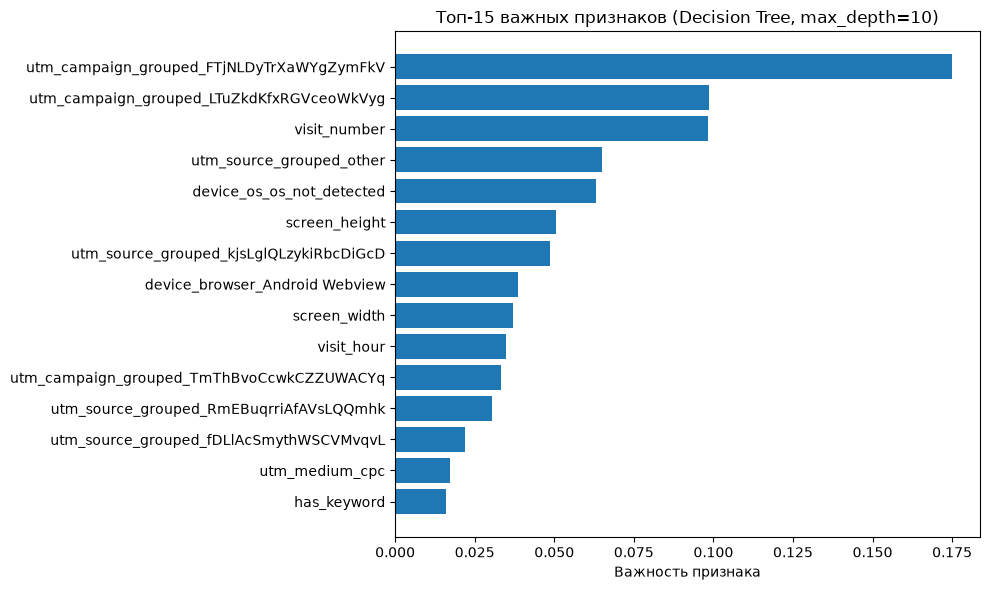

In [149]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel("Важность признака")
plt.title("Топ-15 важных признаков (Decision Tree, max_depth=10)")
plt.tight_layout()
plt.show()

Наиболее влиятельная группа признаков — конкретные источники/кампании трафика (utm_source, utm_campaign), суммарно объясняющие более половины значимости модели. В датасете эти значения анонимизированы, поэтому конкретные рекомендации по кампаниям недоступны, но в проекте открытими данными такой анализ позволил бы точно определить, какие рекламные кампании стоит масштабировать.

Среди интерпретируемых признаков наиболее значимы:\
visit_number - количество визитов пользователя: повторные визиты сильно коррелируют с конверсией, что указывает на ценность ретаргетинга на вернувшихся пользователей;\
visit_hour - час визита: конверсия выше в дневное время;\
device_os_os_not_detected и признаки встроенных браузеров (Android Webview, Safari in-app) - визиты через встроенные браузеры приложений (например, при переходе по ссылке из соцсети) ведут себя иначе, чем визиты из полноценных браузеров;\
screen_width/screen_height - умеренно значимы, вероятно, косвенно отражают тип и класс устройства пользователя.

## Results

### Metrics Analysis

In [150]:
metrics_df = pd.DataFrame({'Dataset': ['Train', 'Test'], 'ROC-AUC': [train_auc, test_auc]})
metrics_df

,Dataset,ROC-AUC
0,Train,0.692108
1,Test,0.679564


На обучающей выборке модель показала ROC-AUC 0.6921, а на тестовой - 0.6796. Значение ROC-AUC на тестовой выборке заметно выше случайного уровня 0.5, что говорит о наличии у модели способности различать целевой и нецелевой классы. Разница между обучающей и тестовой выборками составляет 0.0125, что является небольшой разницей.

### Overfitting / Underfitting Analysis

Разница между ROC-AUC на обучающей и тестовой выборках составляет 0.0125. Небольшой разрыв между значениями метрики указывает на отсутствие выраженного переобучения модели. При этом тестовый ROC-AUC равен 0.6796, что говорит об умеренной способности модели различать целевой и нецелевой классы.

### Saving the Model

In [151]:
joblib.dump(best_model, 'best_decision_tree.pkl')

['best_decision_tree.pkl']

In [152]:
loaded_model = joblib.load('best_decision_tree.pkl')

row_x = X_test.sample(20, random_state=42)
row_y = y_test.loc[row_x.index]

predictions = loaded_model.predict(row_x)
predictions_proba = loaded_model.predict_proba(row_x)[:, 1]

comparison = pd.DataFrame({'real_target': row_y.values, 'predicted_target': predictions, 'predicted_probability': predictions_proba.round(4)})
comparison

,real_target,predicted_target,predicted_probability
0,0,0,0.3941
1,0,1,0.5181
2,0,1,0.5651
3,0,1,0.5549
4,0,0,0.4301
5,0,0,0.4542
6,0,0,0.4477
7,0,0,0.2322
8,0,0,0.4912
9,0,0,0.4477


Точечная проверка на небольшой выборке иллюстрирует поведение модели, но не заменяет основную метрику качества — ROC-AUC на полной тестовой выборке (0.6796), которая учитывает ранжирование вероятностей, а не жёсткую классификацию по порогу 0.5.

### Final Conclusion

В рамках проекта была построена модель бинарной классификации для предсказания вероятности совершения пользователем целевого действия на сайте «СберАвтоподписка» на основе данных о визите (utm-метки, устройство, геолокация, время визита).

Данные. Исходные данные (ga_sessions, ga_hits) объединены по session_id, целевая переменная сформирована как факт наличия хотя бы одного целевого события в сессии. Датасет сильно несбалансирован - целевые визиты составляют ~2.7% от общего числа.

Подготовка данных. Проведена очистка пропусков с сохранением их смысловой природы (например, разделение "нет данных у десктопа" и "аномалия у мобильного устройства"), снижена кардинальность категориальных признаков (группировка топ-N + "other"), созданы новые признаки (день недели, час визита, ширина/высота экрана) с проверкой их связи с целевой переменной. Обнаружено и исправлено несколько скрытых технических аномалий: заглушки в разрешении экрана, боты с нереалистичным разрешением 1600×20000.

Моделирование. Сравнены четыре модели: бейслайн (ROC-AUC 0.50), Logistic Regression (0.668), Decision Tree (0.680) и Random Forest (0.687). В качестве финальной модели выбран Decision Tree — по совокупности качества, скорости и интерпретируемости, несмотря на незначительное отставание от Random Forest по ROC-AUC. После подбора гиперпараметров (max_depth=10, min_samples_leaf=20) итоговая модель показала ROC-AUC = 0.6796 на тестовой выборке — выше ориентировочного значения задания (~0.65) и без признаков выраженного переобучения (разрыв train/test ROC-AUC = 0.0125).

Значимость признаков. Наибольший вклад в предсказание вносят конкретные источники и кампании трафика, а также поведенческие признаки (количество визитов, час визита) и технические особенности устройства (нераспознанная ОС, встроенные браузеры).

Примечание по архитектуре пайплайна. В рамках исследовательского анализа группировка категориальных признаков и заполнение пропусков выполнялись на полном датасете для наглядности и удобства визуализации распределений. В финальном production-пайплайне, реализованном для API, все преобразования (группировка топ-N категорий, медианные значения, границы обрезки выбросов) вычисляются исключительно на обучающей выборке и сохраняются как часть пайплайна для корректного применения к новым данным.

Итог. Модель готова к использованию как основа для сервиса 
предсказания вероятности конверсии по атрибутам визита.